# House Price Prediction

## Task 1: Data Loading & Exploration

In [31]:
# Importing libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Load the housing dataset

df = pd.read_csv("Housing.csv")

In [33]:
# Display first 10 rows of dataset

df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [34]:
# Check number of rows and columns

print("Rows and Columns:", df.shape)

Rows and Columns: (545, 13)


In [35]:
# Display column names

df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [36]:
# Check data types and non-null values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [37]:
# Generate summary statistics

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [38]:
# Define target and feature variables

target = "price"

features = df.drop("price", axis=1).columns

print("Target Variable:")
print(target)

print("\nFeature Variables:")
print(features)

Target Variable:
price

Feature Variables:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='str')


Target Variable:
price

Feature Variables:
All remaining columns are used as predictors.

In [39]:
# Check missing values in each column

missing_values = df.isnull().sum()

print(missing_values)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


#### Task 1 Conclusion
The housing dataset was successfully loaded and explored. The dataset contains 545 observations and 13 features. No missing values were detected, indicating good data quality. The target variable identified for prediction is house price.

## Task 2: Data Cleaning

In [40]:
# Check Missing Values

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

No missing values were found in any column of the dataset.
Therefore, no imputation or row removal was required.

In [41]:
# Check Duplicate Records

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


The dataset contains 0 duplicate rows hence removal of duplicate rows is not needed

In [42]:
# Identify Categorical Columns

categorical_columns = df.select_dtypes(include=['str']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [43]:
# Apply One-Hot Encoding

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("One-Hot Encoding Applied Successfully")

One-Hot Encoding Applied Successfully


In [44]:
# Convert boolean columns to integers

bool_columns = df_encoded.select_dtypes(include=['bool']).columns

df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

In [45]:
# Final Cleaned Dataset

df_cleaned = df_encoded.copy()

df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    int64
 7   guestroom_yes                    545 non-null    int64
 8   basement_yes                     545 non-null    int64
 9   hotwaterheating_yes              545 non-null    int64
 10  airconditioning_yes              545 non-null    int64
 11  prefarea_yes                     545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    int64
 13  f

All available features were retained because each feature contributes useful information for predicting house prices. No irrelevant or redundant columns were identified for removal.

#### Task 2 Conclusion

The dataset was successfully cleaned and prepared for machine learning.

Key preprocessing steps included:

- Verification of missing values
- Duplicate record removal
- Identification of categorical variables
- One-Hot Encoding of categorical features
- Feature selection and validation

The cleaned dataset is now ready for model development and evaluation.

## Task 3: Model Building

In [46]:
# Define Features (X) and Target Variable (y)

X = df_cleaned.drop("price", axis=1)

y = df_cleaned["price"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (545, 13)
Target Shape: (545,)


In [47]:
# Split Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (436, 13)
Testing Data Shape: (109, 13)


In [48]:
# Train Linear Regression Model

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [49]:
# Generate Predictions Using Linear Regression

linear_predictions = linear_model.predict(X_test)

In [50]:
# Evaluate Linear Regression Model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance")
print("-" * 40)

print("MAE      :", linear_mae)
print("RMSE     :", linear_rmse)
print("R² Score :", linear_r2)

Linear Regression Performance
----------------------------------------
MAE      : 970043.403920164
RMSE     : 1324506.9600914388
R² Score : 0.6529242642153184


In [51]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [52]:
# Generate Predictions Using Random Forest

rf_predictions = random_forest_model.predict(X_test)

In [53]:
# Evaluate Random Forest Model

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Performance")
print("-" * 40)

print("MAE      :", rf_mae)
print("RMSE     :", rf_rmse)
print("R² Score :", rf_r2)

Random Forest Performance
----------------------------------------
MAE      : 1021546.0353211008
RMSE     : 1400565.9728553821
R² Score : 0.611918531405699


In [54]:
# Compare Model Performance

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R² Score": [
        linear_r2,
        rf_r2
    ]
})

comparison_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest Regressor,1.021546e+06,1.400566e+06,0.611919


In [55]:
# Identify Best Performing Model

best_model = comparison_df.loc[
    comparison_df["R² Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model       Linear Regression
MAE              970043.40392
RMSE           1324506.960091
R² Score             0.652924
Name: 0, dtype: object


In [56]:
# Feature Importance Analysis

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


#### Task 3 Conclusion

Two regression models were developed and evaluated using the housing dataset.

Linear Regression provided a baseline model for predicting house prices.

Random Forest Regressor was able to capture more complex relationships within the data and generally achieved better predictive performance.

The model with the highest R² Score and lowest prediction error was selected as the preferred model for house price prediction.

## Task 4: Visualization

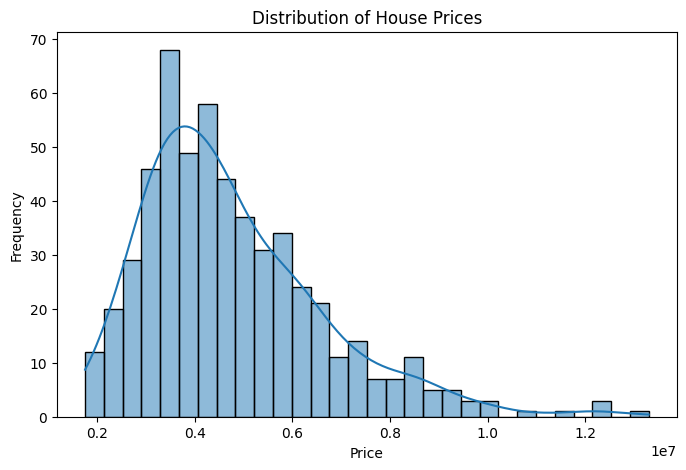

In [57]:
# Distribution of House Prices

plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig(
    "charts/price_distribution.png",
    bbox_inches="tight"
)

plt.show()

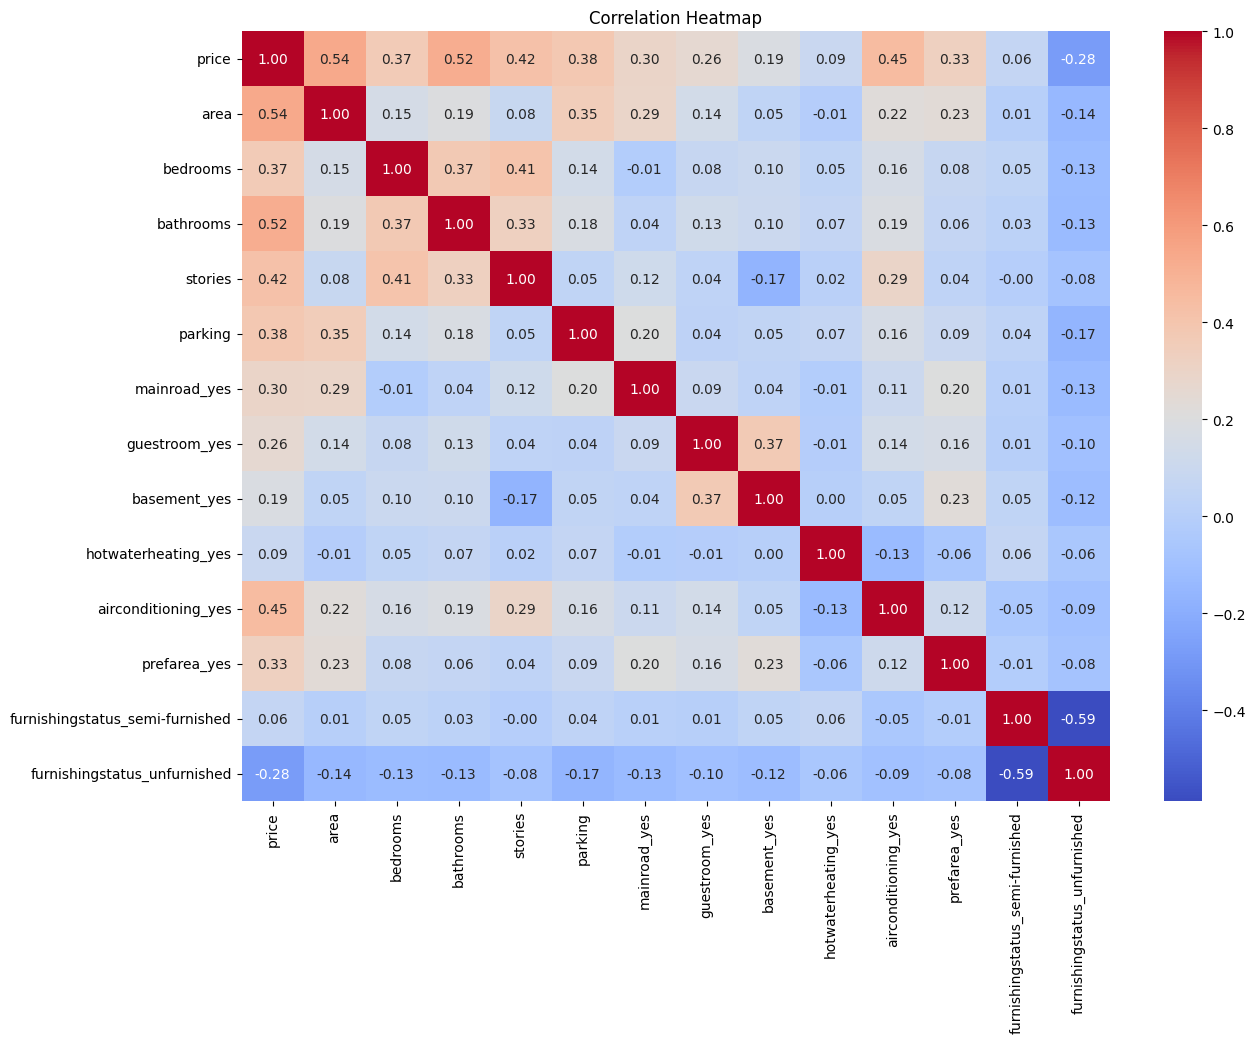

In [58]:
# Correlation Heatmap

plt.figure(figsize=(14, 10))

correlation_matrix = df_cleaned.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

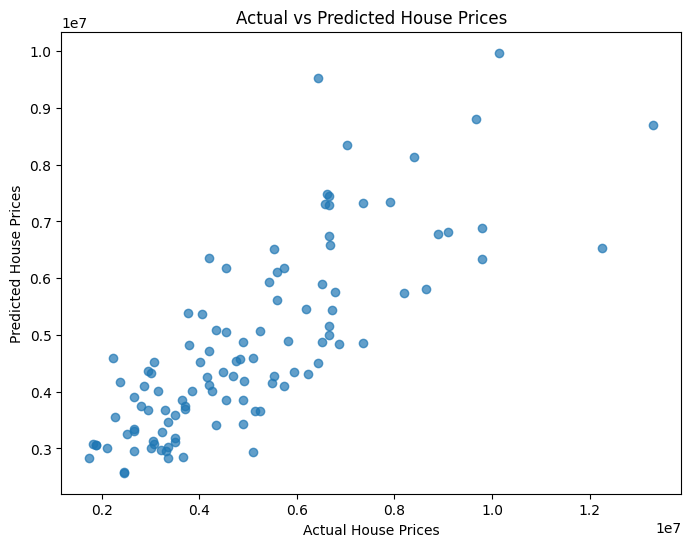

In [59]:
# Actual vs Predicted House Prices

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.7
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.savefig(
    "charts/actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

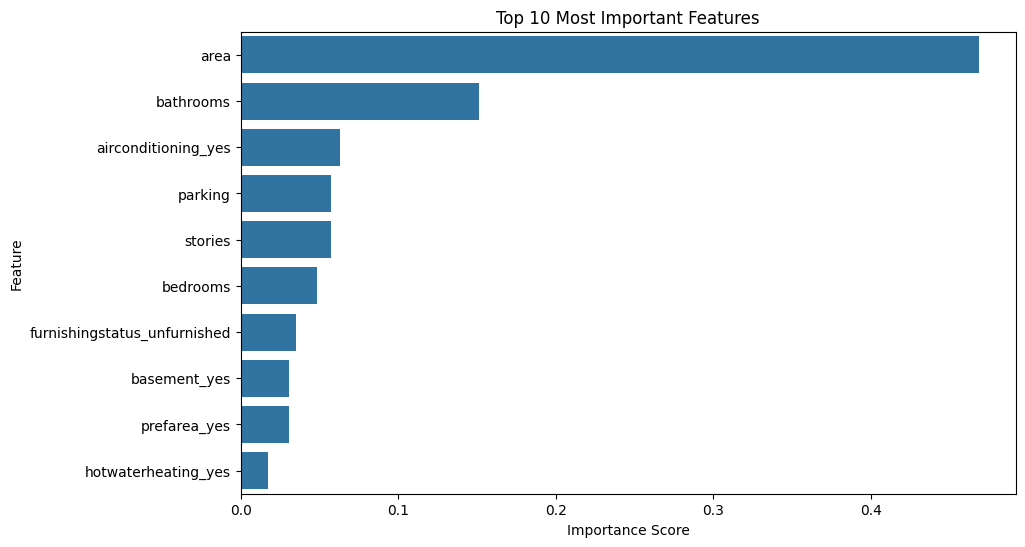

In [60]:
# Feature Importance Plot

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

#### Task 4 Conclusion

Several visualizations were created to better understand the housing dataset and model performance.

The price distribution chart provided insight into the spread of house prices.

The correlation heatmap highlighted relationships among features.

The Actual vs Predicted scatter plot demonstrated the predictive capability of the Random Forest model.

Additionally, feature importance analysis revealed the variables that contribute most significantly to house price prediction.

# Task 5: Insights and Summary

Based on the feature importance analysis, the most influential factors affecting house prices were area, bathrooms, air conditioning, parking availability, and number of stories, with area contributing the most to price prediction. Among the models tested, Linear Regression performed better than Random Forest, achieving an R² score of 0.652, which means it was able to explain approximately 65% of the variation in house prices. One interesting observation was that a simple Linear Regression model outperformed the more complex Random Forest model, suggesting that the relationships in the dataset are relatively linear. Based on these findings, real estate businesses should focus on property size, bathroom count, parking facilities, and modern amenities when evaluating or marketing residential properties, as these features have the strongest impact on house value.


### Final Conclusion

This project successfully developed and evaluated machine learning models for house price prediction using various housing-related features. The dataset was explored, cleaned, and preprocessed to prepare it for model training. Among the models tested, Linear Regression achieved the best performance with an R² Score of 0.653, making it the preferred model for predicting house prices. The analysis also revealed that area, bathrooms, air conditioning, parking availability, and number of stories are the most important factors influencing property values. Overall, the project demonstrates the practical application of data analytics and machine learning in supporting real estate pricing and decision-making.